C:\Users\deepe\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0035 - val_loss: 5.8762e-04
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.7933e-05 - val_loss: 0.0012
Epoch 3/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.7158e-05 - val_loss: 4.6633e-04
Epoch 4/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.5686e-05 - val_loss: 4.5670e-04
Epoch 5/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.5246e-05 - val_loss: 2.7785e-04
Epoch 6/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.5332e-05 - val_loss: 3.3496e-04
Epoch 7/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.4522e-05 - val_loss: 2.1138e-04
Epoch 8/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.3117e-05 - val_loss: 4.9237e-04
Epoch 9/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.4235e-05 - val_loss: 1.9493e-04
Epoch 10/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 1.3325e-05 - val_loss: 2.5178e-04
Epoch 11/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - l

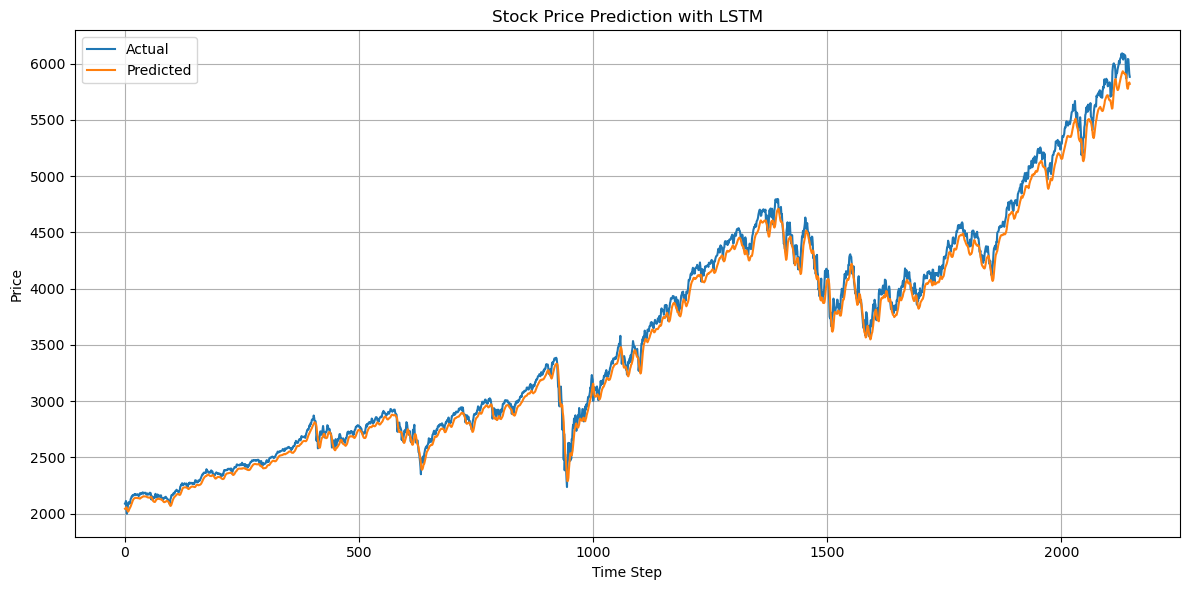

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Load and prepare data
df = pd.read_excel(r"C:\Users\deepe\sp500_historical_data.xlsx", sheet_name="in")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
close_prices = df[['Close']].values

# Scale data
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(close_prices)

# Create sequences
def create_sequences(data, window_size=30):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_close, window_size)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Train-test split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Predict and inverse transform
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_test_orig = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
mae = mean_absolute_error(y_test_orig, y_pred)
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# Plot results
plt.figure(figsize=(12,6))
plt.plot(y_test_orig, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Stock Price Prediction with LSTM')
plt.xlabel('Time Step')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
